# Jena temperature forecasting with an encoder-only transformer

In [1]:
import copy
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cpu")
)

print("Device:", DEVICE)

DAILY_SAMPLES = 144       # 10-minute sampling -> 144 per day
PAST_SEQ = 2 * DAILY_SAMPLES
LAG = 72                  # 12 hours ahead
TARGET_COL = "T (degC)"

# temporal encoding
POS_ENCODING = "time2vec"     # "sinusoidal", "time2vec"

D_MODEL = 64
NUM_HEADS = 4
NUM_LAYERS = 3
FF_DIM = 128
DROPOUT = 0.2
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 35
PATIENCE = 8

Device: cpu


## Load Jena dataset

In [2]:
if "dataframe" not in globals():
    csv_path = "jena_climate_2009_2016.csv"
    dataframe = pd.read_csv(csv_path, index_col=0)

dataframe = dataframe.copy()

print("Data shape:", dataframe.shape)
print("Columns:")
print(list(dataframe.columns))
display(dataframe.head())

Data shape: (420451, 14)
Columns:
['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
# Wind direction is angular, so the raw degree value is not ideal input 
# Convert wd (deg) into cyclic sin/cos features and then drop the raw degree column
df = dataframe.copy()
wd_rad = np.deg2rad(df["wd (deg)"].values)
df["wd_sin"] = np.sin(wd_rad)
df["wd_cos"] = np.cos(wd_rad)
print("Added cyclic wind-direction features: wd_sin, wd_cos")

Added cyclic wind-direction features: wd_sin, wd_cos


### Correlation analysis to detect redundancy

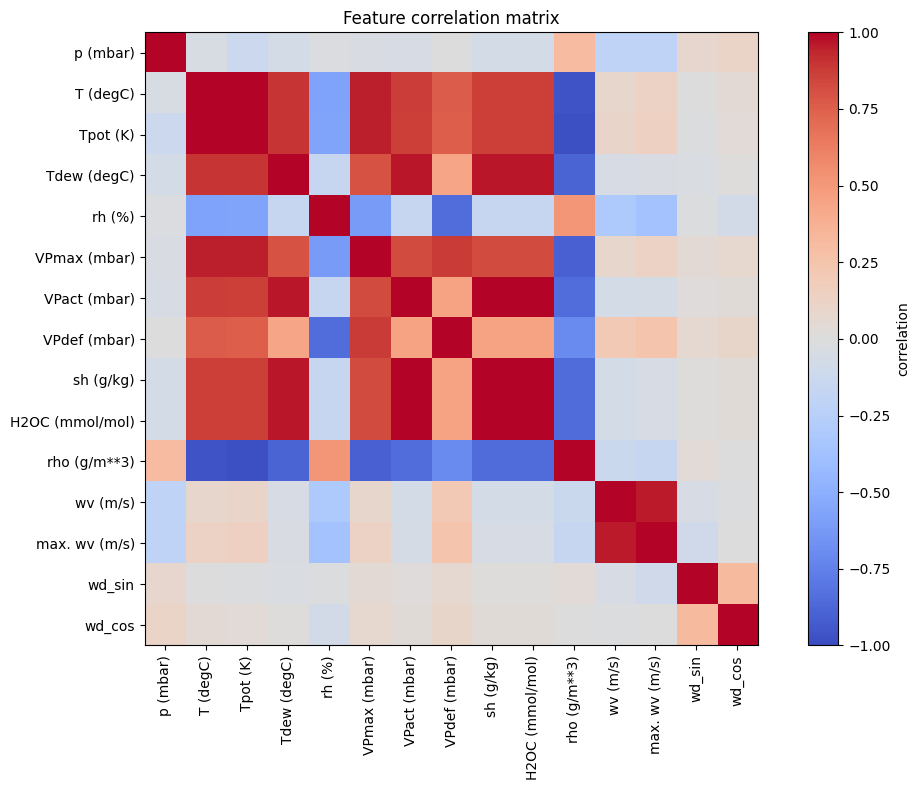

Top absolute correlations:


,level_0,level_1,abs_corr
0,sh (g/kg),H2OC (mmol/mol),0.999997
1,H2OC (mmol/mol),sh (g/kg),0.999997
2,H2OC (mmol/mol),VPact (mbar),0.999856
3,VPact (mbar),H2OC (mmol/mol),0.999856
4,VPact (mbar),sh (g/kg),0.999851
5,sh (g/kg),VPact (mbar),0.999851
6,T (degC),Tpot (K),0.996826
7,Tpot (K),T (degC),0.996826
8,Tpot (K),rho (g/m**3),0.981342
9,rho (g/m**3),Tpot (K),0.981342


In [4]:
corr_df = df.drop(columns=["wd (deg)"]).copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
plt.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label="correlation")
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# show strongest absolute correlations
corr_pairs = (
    corr.abs()
    .where(~np.eye(len(corr), dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

print("Top absolute correlations:")
display(corr_pairs.head(20).rename("abs_corr").reset_index())

The correlation matrix shows strong redundancy among several thermodynamic and moisture-related variables.
In particular, T (degC), Tpot (K), Tdew (degC), VPmax, VPact, VPdef, sh, H2OC, and rho are highly interdependent.
To retain a compact but informative feature set, we keep one representative for temperature, one for pressure,
one for relative humidity, one for wind magnitude, and the cyclic wind-direction pair.

In [5]:
# A compact, defensible reduced set:
# - p (mbar): pressure
# - T (degC): direct target-related thermal state
# - rh (%): relative humidity
# - wv (m/s): wind speed
# - wd_sin, wd_cos: wind direction in cyclic form
#
# We intentionally drop highly derived or redundant thermodynamic variables

KEPT_FEATURES = [
    "p (mbar)",
    "T (degC)",
    "rh (%)",
    "wv (m/s)",
    "wd_sin",
    "wd_cos",
]

target_col = TARGET_COL

print("Kept features:", KEPT_FEATURES)
print("Number of retained input features:", len(KEPT_FEATURES))

Kept features: ['p (mbar)', 'T (degC)', 'rh (%)', 'wv (m/s)', 'wd_sin', 'wd_cos']
Number of retained input features: 6


We keep p, T, rh, wv, wd_sin, and wd_cos.
This preserves pressure, thermal state, humidity, wind magnitude, and wind direction,
while removing variables that are either direct transformations or highly correlated derivatives
of the same physical information.

In [6]:
# retained reduced feature set

feature_array = df[KEPT_FEATURES].values.astype(np.float32)
temperature_array = df[target_col].values.astype(np.float32)

in_sequences, targets = [], []

for i in range(PAST_SEQ, len(df) - LAG, DAILY_SAMPLES):
    in_sequences.append(feature_array[i - PAST_SEQ:i, :])   # [L, N_kept]
    targets.append(temperature_array[i + LAG])              # scalar future temperature

in_sequences = np.asarray(in_sequences, dtype=np.float32)
targets = np.asarray(targets, dtype=np.float32).reshape(-1, 1)

print("Reduced input shape :", in_sequences.shape)
print("Target shape        :", targets.shape)

Reduced input shape : (2918, 288, 6)
Target shape        : (2918, 1)


## Train/validation split and normalization

In [7]:
indices = np.arange(len(in_sequences))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

split = int(0.8 * len(indices))
train_idx = indices[:split]
val_idx = indices[split:]

X_train = in_sequences[train_idx]
X_val = in_sequences[val_idx]
y_train = targets[train_idx]
y_val = targets[val_idx]

x_mean = X_train.mean(axis=(0, 1))
x_std = X_train.std(axis=(0, 1)) + 1e-8

y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0) + 1e-8

X_train_norm = (X_train - x_mean) / x_std
X_val_norm = (X_val - x_mean) / x_std

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std

print("Train:", X_train_norm.shape, y_train_norm.shape)
print("Val  :", X_val_norm.shape, y_val_norm.shape)
print("y_mean:", float(y_mean[0]), "y_std:", float(y_std[0]))

Train: (2334, 288, 6) (2334, 1)
Val  : (584, 288, 6) (584, 1)
y_mean: 11.397871017456055 y_std: 8.738663673400879


In [8]:
# Commonsense persistence style benchmark, adjusted to the same lag logic as the forecasting task
benchmark_celsius = np.mean(
    np.abs(
        temperature_array[DAILY_SAMPLES + LAG::DAILY_SAMPLES]
        - temperature_array[LAG:-(DAILY_SAMPLES - LAG):DAILY_SAMPLES]
    )
)

benchmark_norm = benchmark_celsius / y_std[0]
print(f"Benchmark Celsius: {benchmark_celsius:.4f}")
print(f"Benchmark normalized MAE: {benchmark_norm:.4f}")

Benchmark Celsius: 2.6645
Benchmark normalized MAE: 0.3049


The commonsense benchmark provides a reference MAE in degrees Celsius.
The transformer should ideally beat this baseline, but because the dataset is relatively small,
the improvement over recurrent baselines may be limited.

In [9]:
# PyTorch data loaders
class JenaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = JenaDataset(X_train_norm, y_train_norm)
val_dataset = JenaDataset(X_val_norm, y_val_norm)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train batches: 73
Val batches  : 19


## Positional encodings: sinusoidal and Time2Vec

In [10]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024):
        super().__init__()
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, L, D]

    def forward(self, x):
        # x: [B, L, D]
        return x + self.pe[:, :x.size(1), :]


class Time2Vec(nn.Module):
    # Simple Time2Vec block: one linear term + periodic terms
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        self.w0 = nn.Parameter(torch.randn(1))
        self.b0 = nn.Parameter(torch.zeros(1))
        self.w = nn.Parameter(torch.randn(d_model - 1))
        self.b = nn.Parameter(torch.zeros(d_model - 1))

    def forward(self, x):
        # x is only used for batch and sequence length
        B, L, _ = x.shape
        t = torch.linspace(0, 1, L, device=x.device).view(1, L, 1).repeat(B, 1, 1)

        linear_term = self.w0 * t + self.b0                    # [B, L, 1]
        periodic_term = torch.sin(t * self.w.view(1, 1, -1) + self.b.view(1, 1, -1))

        t2v = torch.cat([linear_term, periodic_term], dim=-1)  # [B, L, D]
        return x + t2v

# Transformer Encoder

In [11]:
# Custom transformer encoder layer that stores attention weights
class ForecastEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )
        self.dropout = nn.Dropout(dropout)

        self.last_attn_weights = None

    def forward(self, x):
        attn_out, attn_weights = self.self_attn(
            query=x,
            key=x,
            value=x,
            need_weights=True,
            average_attn_weights=False,   # keep per-head maps
        )
        self.last_attn_weights = attn_weights.detach()         # [B, H, L, L]

        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

In [12]:
# Encoder-only transformer forecaster
class TimeSeriesTransformerForecaster(nn.Module):
    def __init__(
        self,
        in_features,
        d_model=64,
        num_heads=4,
        num_layers=3,
        ff_dim=128,
        dropout=0.2,
        pos_encoding="time2vec",
    ):
        super().__init__()

        self.input_proj = nn.Linear(in_features, d_model)

        if pos_encoding == "sinusoidal":
            self.pos_encoder = SinusoidalPositionalEncoding(d_model=d_model, max_len=PAST_SEQ)
        elif pos_encoding == "time2vec":
            self.pos_encoder = Time2Vec(d_model=d_model)
        else:
            raise ValueError("pos_encoding must be 'sinusoidal' or 'time2vec'")

        self.encoder_layers = nn.ModuleList([
            ForecastEncoderLayer(d_model, num_heads, ff_dim, dropout=dropout)
            for _ in range(num_layers)
        ])

        self.regression_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, x):
        # x: [B, L, N]
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        for layer in self.encoder_layers:
            x = layer(x)

        pooled = x.mean(dim=1)   # mean-pool over time
        out = self.regression_head(pooled)
        return out

    def get_last_attention_maps(self):
        # return the attention map from the final encoder block
        return self.encoder_layers[-1].last_attn_weights

In [13]:
#Instantiate model, loss, optimizer
model = TimeSeriesTransformerForecaster(
    in_features=len(KEPT_FEATURES),
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT,
    pos_encoding=POS_ENCODING,
).to(DEVICE)

criterion = nn.SmoothL1Loss()   # Huber-style, stable for regression
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
print(model)

TimeSeriesTransformerForecaster(
  (input_proj): Linear(in_features=6, out_features=64, bias=True)
  (pos_encoder): Time2Vec()
  (encoder_layers): ModuleList(
    (0-2): 3 x ForecastEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (regression_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [14]:
# Training and validation loops
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_mae_norm = 0.0
    count = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        with torch.set_grad_enabled(training):
            preds = model(xb)
            loss = criterion(preds, yb)
            mae_norm = F.l1_loss(preds, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_mae_norm += mae_norm.item() * bs
        count += bs

    return total_loss / count, total_mae_norm / count


best_state = None
best_val_loss = float("inf")
best_epoch = -1
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_mae_norm": [],
    "val_mae_norm": [],
    "train_mae_c": [],
    "val_mae_c": [],
}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_mae_norm = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_mae_norm = run_epoch(model, val_loader, optimizer=None)

    train_mae_c = train_mae_norm * y_std[0]
    val_mae_c = val_mae_norm * y_std[0]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae_norm"].append(train_mae_norm)
    history["val_mae_norm"].append(val_mae_norm)
    history["train_mae_c"].append(train_mae_c)
    history["val_mae_c"].append(val_mae_c)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
        f"train_MAE_C={train_mae_c:.4f} val_MAE_C={val_mae_c:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"Best epoch: {best_epoch}, best val loss: {best_val_loss:.4f}")

Epoch 01 | train_loss=0.1478 val_loss=0.0913 | train_MAE_C=3.7840 val_MAE_C=2.9755
Epoch 02 | train_loss=0.0981 val_loss=0.0804 | train_MAE_C=3.0689 val_MAE_C=2.6869
Epoch 03 | train_loss=0.0868 val_loss=0.0744 | train_MAE_C=2.9115 val_MAE_C=2.6033
Epoch 04 | train_loss=0.0828 val_loss=0.0798 | train_MAE_C=2.8173 val_MAE_C=2.6397
Epoch 05 | train_loss=0.0775 val_loss=0.0886 | train_MAE_C=2.7268 val_MAE_C=2.9369
Epoch 06 | train_loss=0.0751 val_loss=0.0829 | train_MAE_C=2.6842 val_MAE_C=2.7451
Epoch 07 | train_loss=0.0667 val_loss=0.0693 | train_MAE_C=2.5276 val_MAE_C=2.4908
Epoch 08 | train_loss=0.0658 val_loss=0.0586 | train_MAE_C=2.5214 val_MAE_C=2.3303
Epoch 09 | train_loss=0.0615 val_loss=0.0612 | train_MAE_C=2.4117 val_MAE_C=2.3936
Epoch 10 | train_loss=0.0619 val_loss=0.0556 | train_MAE_C=2.4107 val_MAE_C=2.2837
Epoch 11 | train_loss=0.0592 val_loss=0.0590 | train_MAE_C=2.3322 val_MAE_C=2.2651
Epoch 12 | train_loss=0.0556 val_loss=0.0538 | train_MAE_C=2.2955 val_MAE_C=2.1974
Epoc

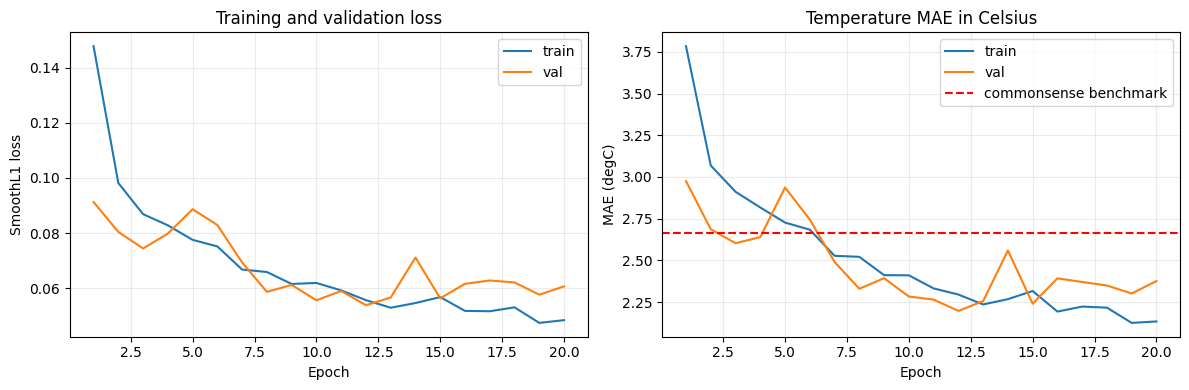

In [15]:
epochs_ran = len(history["train_loss"])
x_axis = np.arange(1, epochs_ran + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(x_axis, history["train_loss"], label="train")
plt.plot(x_axis, history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1 loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.25)

plt.subplot(1, 2, 2)
plt.plot(x_axis, history["train_mae_c"], label="train")
plt.plot(x_axis, history["val_mae_c"], label="val")
plt.axhline(benchmark_celsius, color="red", linestyle="--", label="commonsense benchmark")
plt.xlabel("Epoch")
plt.ylabel("MAE (degC)")
plt.title("Temperature MAE in Celsius")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

The training curves decrease steadily, and the best validation performance is reached at epoch 12 before early stopping.
The best validation MAE is 2.1974 °C, which is below the commonsense benchmark of 2.6645 °C by 0.4672 °C.
This shows that the transformer learns useful temporal structure, although the improvement remains moderate, which is consistent with the expectation that transformers may be less data-efficient than recurrent models on smaller datasets.

In [16]:
val_loss, val_mae_norm = run_epoch(model, val_loader, optimizer=None)
val_mae_c = val_mae_norm * y_std[0]

print(f"Final validation loss     : {val_loss:.4f}")
print(f"Final validation MAE norm : {val_mae_norm:.4f}")
print(f"Final validation MAE (C)  : {val_mae_c:.4f}")
print(f"Benchmark MAE (C)         : {benchmark_celsius:.4f}")
print(f"Improvement over benchmark: {benchmark_celsius - val_mae_c:.4f} degC")

Final validation loss     : 0.0538
Final validation MAE norm : 0.2515
Final validation MAE (C)  : 2.1974
Benchmark MAE (C)         : 2.6645
Improvement over benchmark: 0.4672 degC


The final validation MAE is 2.1974 °C, compared with a commonsense benchmark of 2.6645 °C.
Therefore, the transformer beats the benchmark by 0.4672 °C.
This comparison is against a simple persistence-style baseline; it is not yet a direct comparison against the GRU/LSTM models from Notebook 7.1.

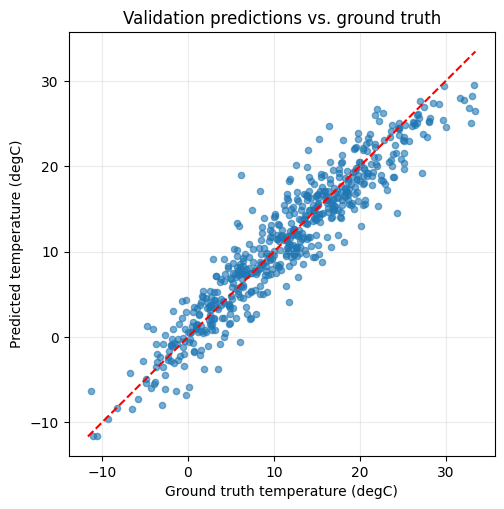

In [17]:
# Denormalized predictions vs ground truth
model.eval()
preds_list = []
targets_list = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        preds = model(xb).cpu().numpy()
        preds_list.append(preds)
        targets_list.append(yb.numpy())

preds_norm = np.vstack(preds_list)
targets_norm_full = np.vstack(targets_list)

preds_c = preds_norm * y_std + y_mean
targets_c = targets_norm_full * y_std + y_mean

plt.figure(figsize=(5.5, 5.5))
plt.scatter(targets_c, preds_c, alpha=0.6, s=20)
mn = min(targets_c.min(), preds_c.min())
mx = max(targets_c.max(), preds_c.max())
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("Ground truth temperature (degC)")
plt.ylabel("Predicted temperature (degC)")
plt.title("Validation predictions vs. ground truth")
plt.grid(alpha=0.25)
plt.show()

The validation scatter plot is concentrated around the identity line, which indicates that the model captures the overall temperature trend reasonably well.
Some spread around the line remains, showing that the forecasts are still imperfect and somewhat smoothed toward the mean, which is typical for a modest-sized transformer trained on this dataset.

In [18]:
# extracting attention maps from trained model
def get_attention_for_sample(model, x_single):
    """
    x_single: numpy array [L, N]
    returns:
        pred_celsius
        attn_maps [num_heads, L, L] from the final encoder block
    """
    model.eval()
    x_tensor = torch.tensor(x_single[None, ...], dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred_norm = model(x_tensor).cpu().numpy()[0, 0]
        attn_maps = model.get_last_attention_maps().cpu().numpy()[0]  # [H, L, L]

    pred_c = pred_norm * y_std[0] + y_mean[0]
    return pred_c, attn_maps

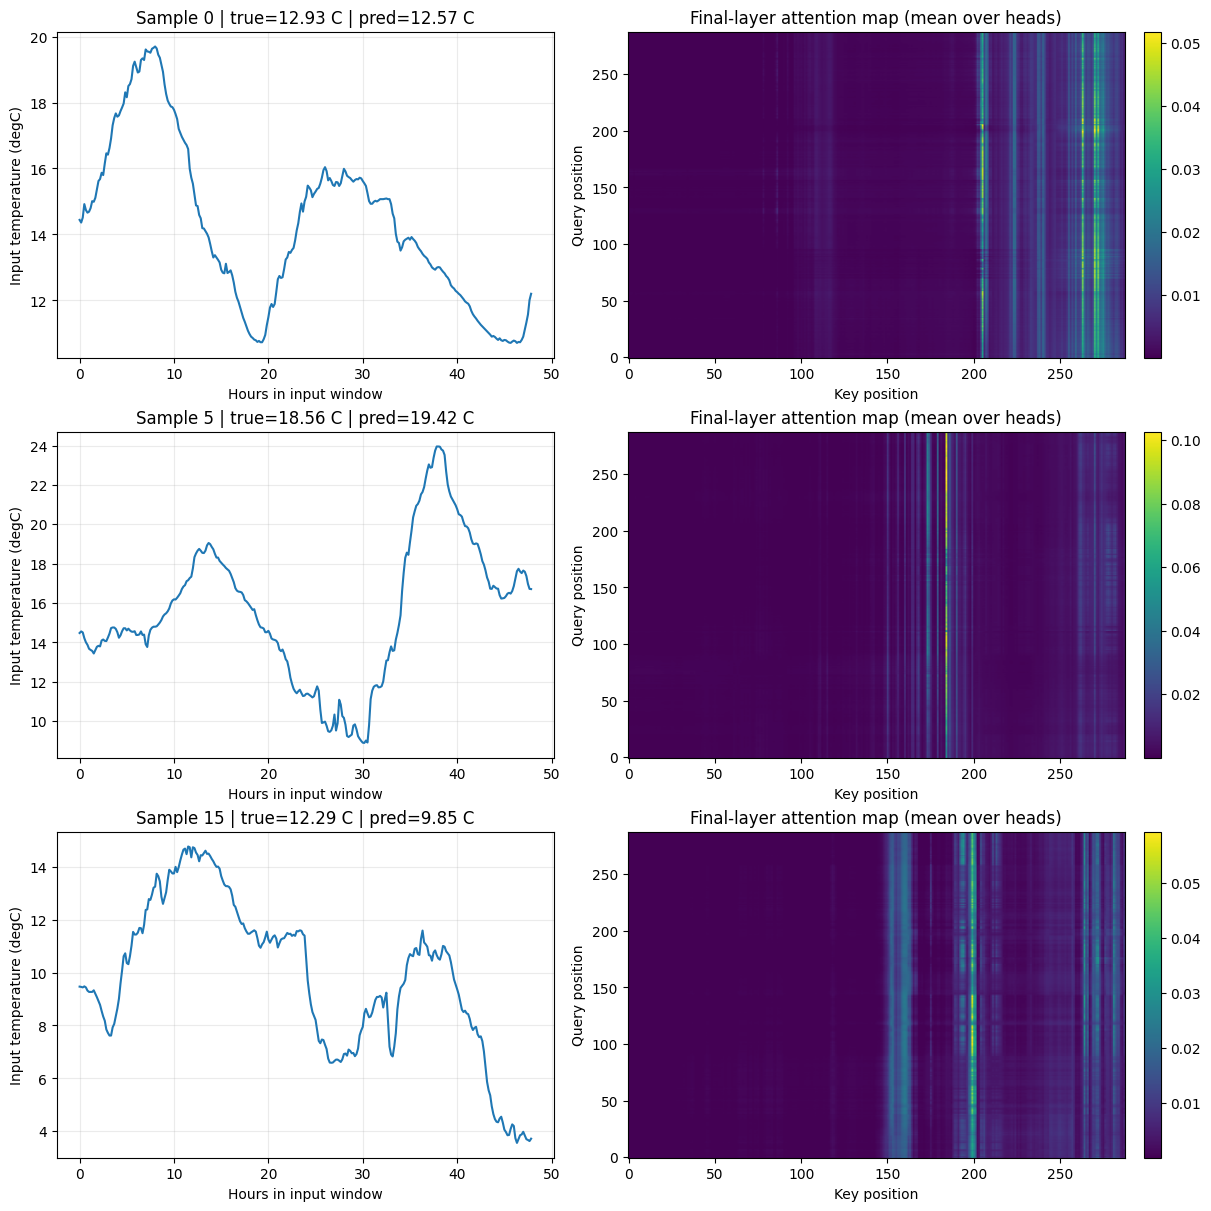

In [19]:
def plot_attention_samples(model, X_val_norm, y_val, val_idx_list, head_mode="mean"):
    """
    head_mode:
        - "mean": average over heads
        - integer: select one head index
    """
    n = len(val_idx_list)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), constrained_layout=True)

    if n == 1:
        axes = np.array([axes])

    for row, idx in enumerate(val_idx_list):
        x_seq = X_val_norm[idx]
        pred_c, attn_maps = get_attention_for_sample(model, x_seq)

        if head_mode == "mean":
            attn_show = attn_maps.mean(axis=0)
            attn_title = "mean over heads"
        else:
            attn_show = attn_maps[head_mode]
            attn_title = f"head {head_mode}"

        true_c = y_val[idx, 0]

        # left: temperature trace from the retained sequence
        temp_pos = KEPT_FEATURES.index("T (degC)")
        temp_trace_norm = x_seq[:, temp_pos]
        temp_trace_c = temp_trace_norm * x_std[temp_pos] + x_mean[temp_pos]

        axes[row, 0].plot(np.arange(len(temp_trace_c)) / 6.0, temp_trace_c, lw=1.5)
        axes[row, 0].set_title(f"Sample {idx} | true={true_c:.2f} C | pred={pred_c:.2f} C")
        axes[row, 0].set_xlabel("Hours in input window")
        axes[row, 0].set_ylabel("Input temperature (degC)")
        axes[row, 0].grid(alpha=0.25)

        im = axes[row, 1].imshow(attn_show, origin="lower", aspect="auto", cmap="viridis")
        axes[row, 1].set_title(f"Final-layer attention map ({attn_title})")
        axes[row, 1].set_xlabel("Key position")
        axes[row, 1].set_ylabel("Query position")
        plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)

    plt.show()


VAL_SAMPLES_TO_PLOT = [0, 5, 15]
plot_attention_samples(
    model=model,
    X_val_norm=X_val_norm,
    y_val=y_val,
    val_idx_list=VAL_SAMPLES_TO_PLOT,
    head_mode="mean",
)

The trained attention maps are clearly more structured than the untrained maps from the earlier notebook.
The dominant pattern is a near-diagonal concentration, indicating that the model relies strongly on local temporal context.
At the same time, some broader sample-dependent structure is visible away from the diagonal, which suggests that the model also uses longer-range temporal relations in selected cases.
The attention patterns are not identical across validation windows, indicating that the model adapts its focus to the characteristics of each input sequence.

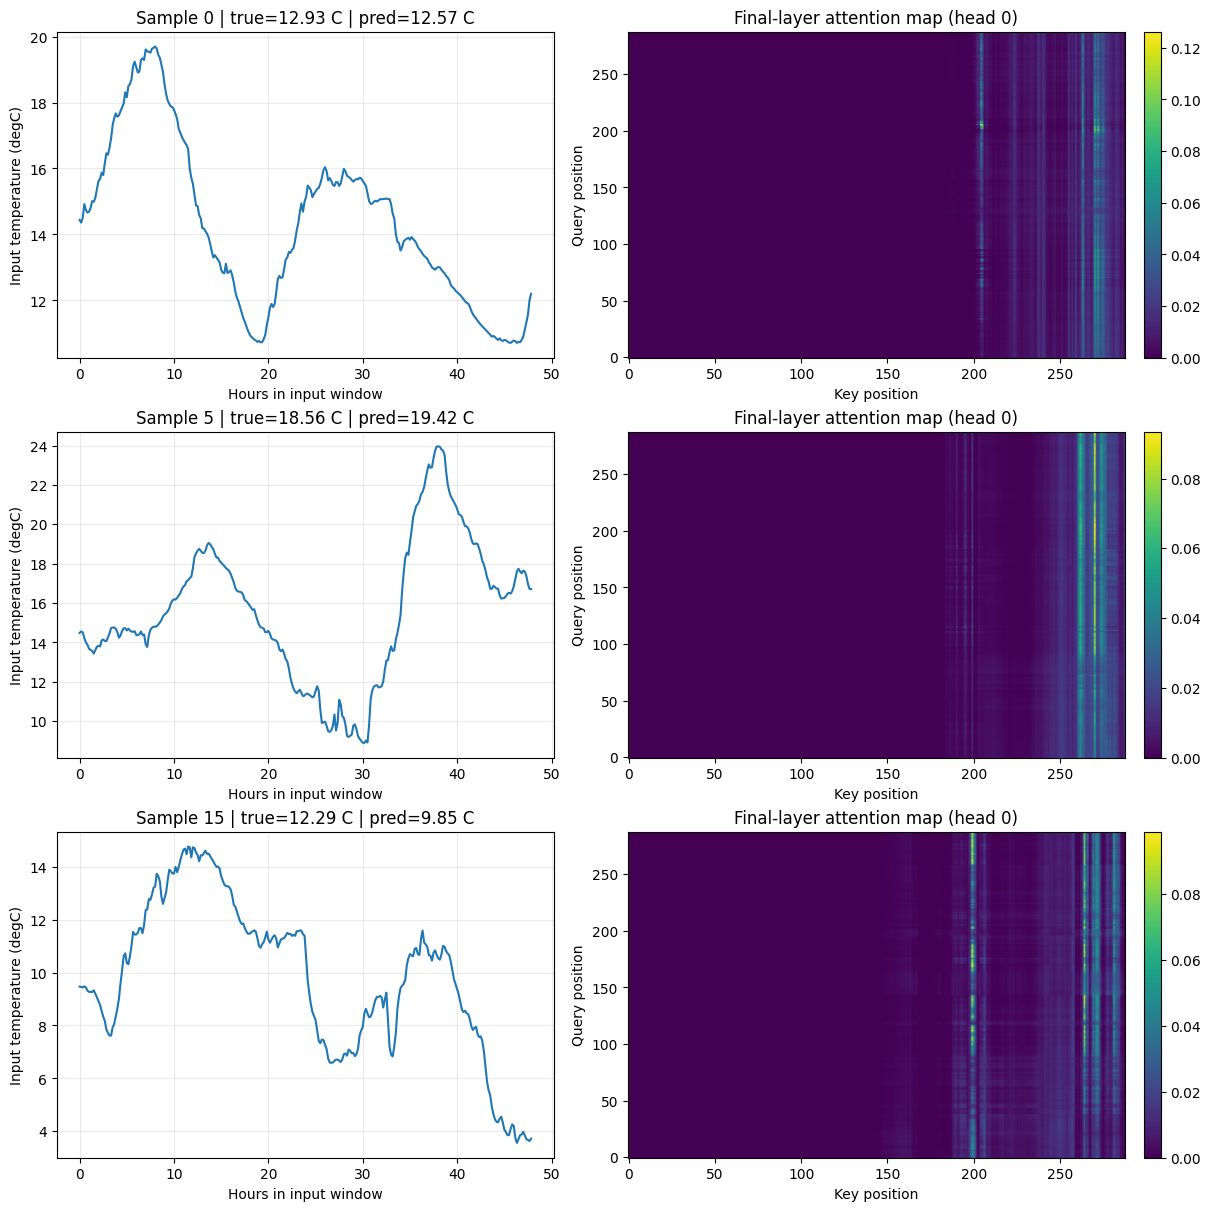

In [20]:
# If the mean-over-heads map looks too smooth, inspect individual heads instead of the head-average

plot_attention_samples(
    model=model,
    X_val_norm=X_val_norm,
    y_val=y_val,
    val_idx_list=VAL_SAMPLES_TO_PLOT,
    head_mode=0,
)


A reduced feature set consisting of p, T, rh, wv, wd_sin, and wd_cos was used after pruning highly redundant thermodynamic and moisture-derived variables identified through the correlation analysis.  
The transformer encoder from Project 8.B was adapted to time-series regression by replacing the text embedding stage with a linear projection of continuous weather features and replacing the classification head with a scalar regression head.  
Time2Vec was used as the temporal encoding, which is appropriate because the task explicitly allows either periodic positional encoding or Time2Vec.  
The trained model achieved a final validation MAE of 2.1974 °C, outperforming the commonsense benchmark of 2.6645 °C by 0.4672 °C.  
The attention maps show mainly local, near-diagonal temporal dependence together with some broader sample-specific long-range structure.  
Overall, the moderate size of the performance gain is consistent with the fact that transformer models are often less data-efficient than recurrent models on relatively small time-series datasets.

---------------------------------------------------------------------------------------------------------------------------------